In [1]:
import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

import warnings

from IPython.display import HTML

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns

import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, f1_score, precision_score, recall_score

from nltk.corpus import stopwords
import re
from collections import Counter

from tqdm.auto import tqdm

In [2]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda', index=0)

In [3]:
color_list = ['#faa5c7', '#eb679c', '#cc3d76', '#b3245d', '#d40457', '#8f1042', '#6e042e']
color_palette = sns.color_palette(color_list)
sns.set_palette(color_palette)

# cmap = colors.ListedColormap(color_palette)
cmap = LinearSegmentedColormap.from_list('custom_palette', color_list, N=256)

warnings.filterwarnings("ignore")

In [4]:
data=pd.read_csv('/kaggle/input/emotions-twitterv3/modelling_after_pp_V3.csv')
data.head()

,Unnamed: 0.1,Unnamed: 0,text,label,Label_String
0,0,1,i have enjoyed being able to slouch about rela...,0,sadness
1,1,2,i gave up my internship with the dmrg and am f...,4,fear
2,2,3,i do not know i feel so lost,0,sadness
3,3,4,i am a kindergarten teacher and i am thoroughl...,4,fear
4,4,5,i was beginning to feel quite disheartened,0,sadness


In [5]:
def getVocabulory(sentenceList, noTopWords):
    wordList = []
    
    for sentence in sentenceList:
        for word in sentence.lower().split():
            wordList.append(word)

    corpus = Counter(wordList)
    if(noTopWords>len(corpus)):
        noTopWords=len(corpus)
        print("number of top words is greater than length of unique words, using whole corpus, number of words: ",noTopWords)
    corpus_ = sorted(corpus,key=corpus.get,reverse=True)[:noTopWords]
    onehot_dict = {w:i+1 for i,w in enumerate(corpus)}
    
    return onehot_dict

In [6]:
def preprocessData(data: pd.DataFrame):
    X, y = data.loc[:, 'text'].values, data.loc[:, 'label'].values
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = .2, stratify = y)
    print(f'X_train {X_train.shape} | X_test {X_test.shape} | y_train {y_train.shape} | y_test {y_test.shape}')
    
    noTopWords=20000
    vocab = getVocabulory(X_train,noTopWords)
    
    new_X_train, new_X_test = [], []
    
    for sentence in X_train:
        new_X_train.append([vocab[word] for word in sentence.lower().split() if word in vocab.keys()])
        
    for sentence in X_test:
        new_X_test.append([vocab[word] for word in sentence.lower().split() if word in vocab.keys()])
    
    return new_X_train, new_X_test, y_train, y_test, vocab

In [7]:
def padding(sentences, seq_len):
    features = np.zeros((len(sentences), seq_len),dtype=int)
    for ii, tweet in enumerate(sentences):
        if len(tweet) != 0:
            features[ii, -len(tweet):] = np.array(tweet)[:seq_len]
    return features

In [8]:
X_train, X_test, y_train, y_test, vocab = preprocessData(data)

X_train (295674,) | X_test (73919,) | y_train (295674,) | y_test (73919,)


In [9]:
X_train = padding(X_train, 280)
X_test = padding(X_test, 280)

In [10]:
X_train, y_train = torch.Tensor(X_train), torch.Tensor(y_train).to(torch.long)
X_test, y_test = torch.Tensor(X_test), torch.Tensor(y_test).to(torch.long)

In [11]:
train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

batch_size = 32

train_dataloader = DataLoader(train_dataset, batch_size = batch_size, shuffle = True, drop_last = True)
test_dataloader = DataLoader(test_dataset, batch_size = batch_size, drop_last = True)

In [12]:
def makeTheNet(no_layers=2,hidden_dim=128,embedding_dim=64):
    class EmotionsRNN(nn.Module):
        def __init__(self, no_layers, vocab_size, hidden_dim, embedding_dim, output_dim):
            super().__init__()

            self.no_layers = no_layers
            self.hidden_dim = hidden_dim
            self.output_dim = output_dim

            # Embedding Layer
            self.embedding = nn.Embedding(vocab_size, embedding_dim)

            # LSTM Layers
            self.lstm = nn.LSTM(
                input_size=embedding_dim,
                hidden_size=hidden_dim,
                num_layers=no_layers,
                batch_first=True,
            )

            # Dropout to reduce overfitting
            self.dropout = nn.Dropout(0.5)

            # Fully Connected Layers with BatchNorm and Dropout
            self.fc1 = nn.Linear(hidden_dim, hidden_dim // 2)  # Reduce size to decrease complexity
            self.bn1 = nn.BatchNorm1d(hidden_dim // 2)  # BatchNorm
            self.fc2 = nn.Linear(hidden_dim // 2, hidden_dim // 4)  # Further reduction
            self.bn2 = nn.BatchNorm1d(hidden_dim // 4)
            self.output = nn.Linear(hidden_dim // 4, output_dim)  # Final output layer

        def forward(self, x, hidden):
            # Embedding and LSTM
            x = self.embedding(x)
            x, hidden = self.lstm(x, hidden)
            x = x[:, -1, :]  # Use last output for classification
            x = self.dropout(x)  # Apply dropout

            # Fully Connected Layers with ReLU, BatchNorm, and Dropout
            x = F.relu(self.fc1(x))
            x = self.bn1(x)  # Apply batch normalization
            x = F.dropout(x, 0.5)  # Apply dropout
            
            x = F.relu(self.fc2(x))
            x = self.bn2(x)
            x = F.dropout(x, 0.5)  # Additional dropout for regularization
            
            return self.output(x), hidden  # Output layer

        def init_hidden(self, batch_size):
            # Initialize hidden states
            h0 = torch.zeros((self.no_layers, batch_size, self.hidden_dim)).to(device)
            c0 = torch.zeros((self.no_layers, batch_size, self.hidden_dim)).to(device)
            hidden = (h0, c0)
            return hidden

    # Create the model with modified layer dimensions
    net = EmotionsRNN(
        no_layers=no_layers,
        hidden_dim=hidden_dim,
        output_dim=6,
        embedding_dim=embedding_dim,
        vocab_size=len(vocab) + 1,
    )

    # Loss function and optimizer with L2 regularization
    lossfun = nn.CrossEntropyLoss()  # Binary classification
    optimizer = torch.optim.Adam(net.parameters(), lr = .0001)  # L2 regularization
    
    return net, lossfun, optimizer

In [13]:
# import itertools

# embedding_dim_values = [32, 64, 128]
# hidden_dim_values = [64, 128, 256]
# no_layers_values = [1, 2, 3]

# best_params = None
# best_validation_loss = float('inf')

# for embedding_dim, hidden_dim, no_layers in itertools.product(embedding_dim_values, hidden_dim_values, no_layers_values):
#     print("Testing configuration: embedding_dim={}, hidden_dim={}, no_layers={}".format(embedding_dim, hidden_dim, no_layers))
    
#     net, lossfun, optimizer = makeTheNet(no_layers,hidden_dim,embedding_dim)
#     print(net)
    
#     # Train the model
#     trainAcc, testAcc, trainLoss, testLoss, net, yTrue, yPred = trainTheNet()
    
#     # Evaluate the model on validation set
#     validation_loss = testLoss[-1]  # Assuming testLoss stores validation loss
    
#     # Print validation loss
#     print("Validation Loss:", validation_loss)
    
#     # Check if this configuration is better than the previous best
#     if validation_loss < best_validation_loss:
#         best_validation_loss = validation_loss
#         best_params = (embedding_dim, hidden_dim, no_layers)

# print("Grid search complete.")
# print("Best hyperparameters found:", best_params)


In [14]:
# net, lossfun, optimizer = makeTheNet()
# net

EmotionsRNN(
  (embedding): Embedding(63334, 64)
  (lstm): LSTM(64, 128, num_layers=2, batch_first=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=128, out_features=64, bias=True)
  (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (bn2): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (output): Linear(in_features=32, out_features=6, bias=True)
)

In [15]:
X, y = next(iter(train_dataloader))
X.shape, y.shape

(torch.Size([32, 280]), torch.Size([32]))

In [16]:
Xt, yt = next(iter(test_dataloader))
Xt.shape, yt.shape

(torch.Size([32, 280]), torch.Size([32]))

In [17]:
class EarlyStopper:
    def __init__(self, patience=1, min_deltaG=0.02,min_deltaL=0.005):
        self.patience = patience
        self.min_deltaG = min_deltaG
        self.min_deltaL = min_deltaL
        self.counterG = 0
        self.counterL = 0
        self.min_validation_loss = float('inf')

    def early_stop(self, validation_loss):
        if validation_loss < self.min_validation_loss:
            if(self.min_validation_loss-validation_loss<self.min_deltaL):
                self.counterL += 1
                if self.counterL >= self.patience:
                    print("smanjilo se dva puta")
                    print(self.counterL)
                    print("self.min_validation_loss ",self.min_validation_loss)
                    print('self.min_delta ',self.min_deltaL)
                    print('validation_loss ',validation_loss)
                    return True
            self.counterG = 0
            self.min_validation_loss = validation_loss
        elif validation_loss > (self.min_validation_loss + self.min_deltaG):
            self.counterG += 1
            self.counterL = 0
            if self.counterG >= self.patience:
                print("povecalo se dva puta")
                print(self.counterG)
                print("self.min_validation_loss ",self.min_validation_loss)
                print('self.min_delta ',self.min_deltaG)
                print('validation_loss ',validation_loss)
                return True
        return False

In [18]:
def trainTheNet():
    clip = 5
    epochs = 20
    
    net, lossfun, optimizer = makeTheNet()
    net.to(device)
    
    trainAcc = []
    trainLoss = []
    testAcc = []
    testLoss = []
    
    yTrue = []
    yPred = []
   
    
    early_stopper = EarlyStopper(patience=2, min_deltaG=0.02, min_deltaL=0.001)
    for epochi in tqdm(range(epochs)):
        batchAcc = []
        batchLoss = []
        
        h = net.init_hidden(batch_size)
        
        net.train()
        
        for X, y in train_dataloader:
            X, y = X.to(device, dtype=torch.int), y.to(device)
            h = tuple([each.data for each in h])
            yHat, h = net(X, h)
            yHat = yHat.squeeze()
            loss = lossfun(yHat, y)
            
            batchAcc.append(100*torch.mean((torch.argmax(yHat.cpu(), axis = 1) == y.cpu()).float()))
            batchLoss.append(loss.item())
            
            optimizer.zero_grad()
            loss.backward()
            
            nn.utils.clip_grad_norm_(net.parameters(), clip)
            optimizer.step()
        
        trainAcc.append(np.mean(batchAcc))
        trainLoss.append(np.mean(batchLoss))
        
        net.eval()
        
        with torch.no_grad():
            
            h = net.init_hidden(batch_size)
        
            batchAcc = []
            batchLoss = []
            for X, y in test_dataloader:
                X, y = X.to(device, dtype=torch.int), y.to(device)
                h = tuple([each.data for each in h])
                yHat, h = net(X, h)
                yHat = yHat.squeeze()
                loss = lossfun(yHat, y)
                
                if epochi == epochs - 1:
                    yTrue.extend(y)
                    yPred.extend(torch.argmax(yHat, axis = 1))
                
                batchAcc.append(100*torch.mean((torch.argmax(yHat.cpu(), axis = 1) == y.cpu()).float()))
                batchLoss.append(loss.item())

            testAcc.append(np.mean(batchAcc))
            testLoss.append(np.mean(batchLoss))
        
        print(testLoss[-1])
        if early_stopper.early_stop(testLoss[-1]):  
            yTrue.extend(y)
            yPred.extend(torch.argmax(yHat, axis = 1))
            break
            
            
        
    return trainAcc, testAcc, trainLoss, testLoss, net, yTrue, yPred


In [19]:
trainAcc, testAcc, trainLoss, testLoss, net, yTrue, yPred = trainTheNet()

  0%|          | 0/20 [00:00<?, ?it/s]

1.2235746993911167
0.5348937517671731
0.25971987058282314
0.1441102121767478
0.08690638904622726
0.07673883202789056
0.06056502486028605
0.067761041362287
0.04894571675658436
0.04453118619819844
0.040004123381548046
0.03938736244064695
0.03467827042764632
0.03763837399417571
0.03621103716677275
0.03817186562974267
0.034686713397991564
0.03862421528130981
0.039577466727599084
0.03885663269652884


In [20]:
len(yTrue)

73888

In [21]:
torch.save(net.state_dict(), 'emotions_classification.pth')

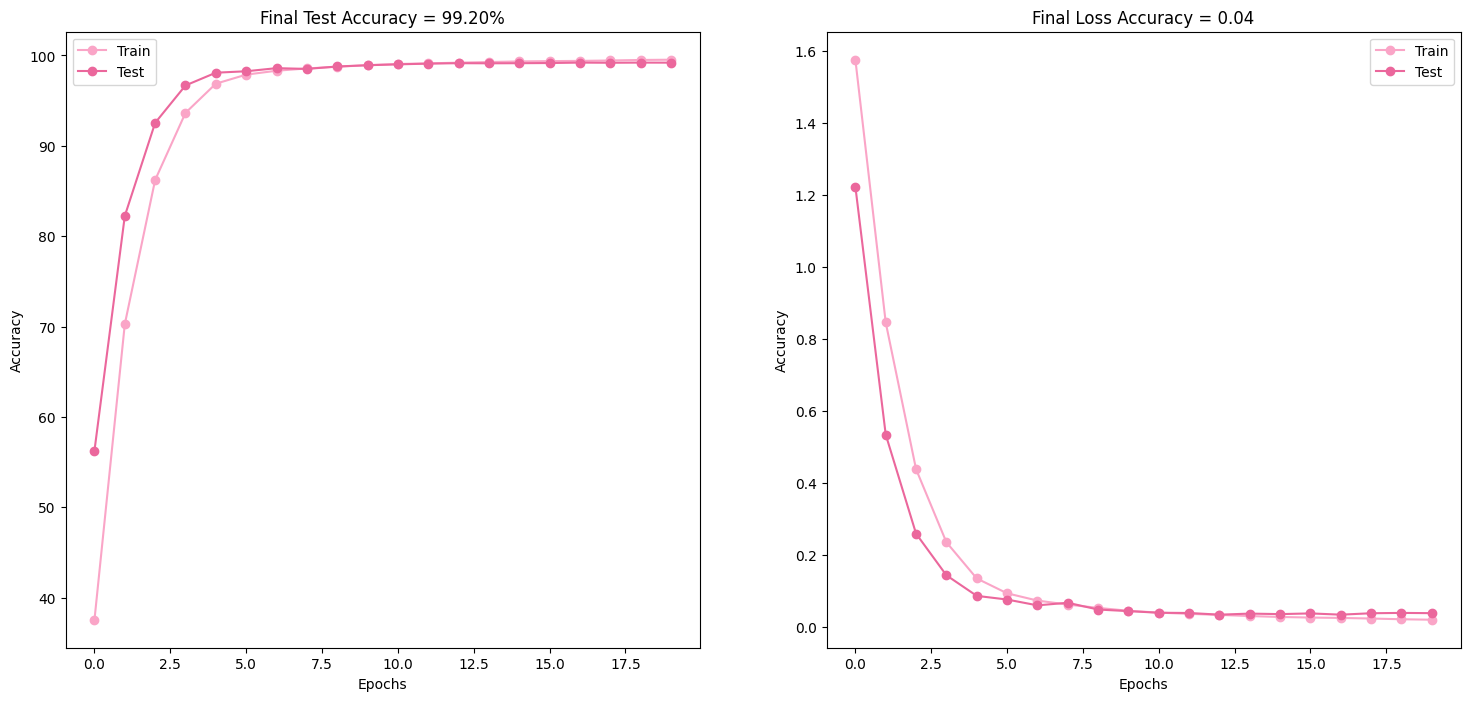

In [22]:
fig, ax = plt.subplots(1, 2, figsize = (18, 8))

ax[0].plot(trainAcc, 'o-', label = 'Train')
ax[0].plot(testAcc, 'o-', label = 'Test')
ax[0].set_title(f'Final Test Accuracy = {testAcc[-1]:.2f}%')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Accuracy')
ax[0].legend()

ax[1].plot(trainLoss, 'o-', label = 'Train')
ax[1].plot(testLoss, 'o-', label = 'Test')
ax[1].set_title(f'Final Loss Accuracy = {testLoss[-1]:.2f}')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Accuracy')
ax[1].legend()

plt.show()

In [23]:
yTrue, yPred = [yT.item() for yT in yTrue], [yP.item() for yP in yPred]

In [24]:
len(yPred)

73888

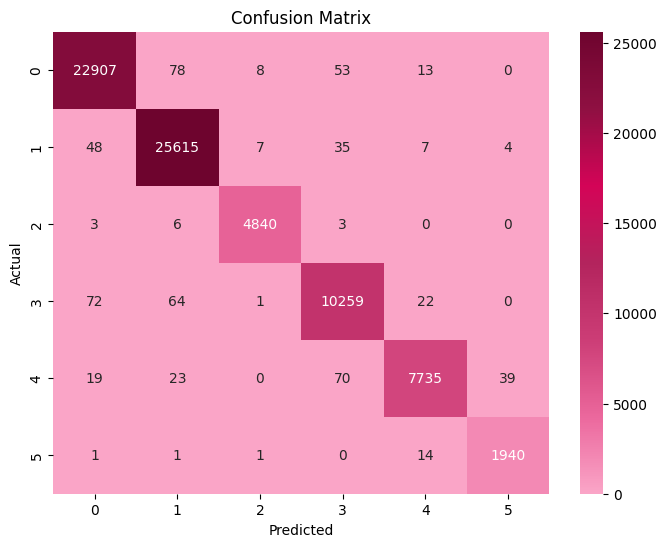

In [25]:
cm = confusion_matrix(yTrue, yPred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, cmap=cmap, fmt='g')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [26]:
precision = precision_score(yTrue, yPred, average = 'micro')
recall = recall_score(yTrue, yPred, average = 'micro')
f1Score = f1_score(yTrue, yPred, average = 'micro')

In [27]:
precision

0.9919878735383283

In [28]:
recall

0.9919878735383283

In [29]:
f1Score

0.9919878735383283